### This notebook compute "VSS2. Percentage of irrigation water rate collection" indicator for the 27 basins of IKI Project

Spanish: Porcentaje de la recaudación de la tarifa de agua de riego 

**Created:** 11/10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:**
**Status:** Complete and loaded in SQLite. 
**QA Status:** reviewed by  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
 
**Inputs:**   Shapefile of COMIDs and districts,  la recaudacion efectiva de la junta de usuarios (Excel Recaudación tarifa agrario.xlsx recieved from Fronseca)

**Outputs:** 
 
**Assumptions:** If multiple ALAS overlap a subbasin, aggregate, group by COMID and take the mean of tariff values
 
**Future work:** Normalize. 
 
**Notes:** 

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
import unicodedata

In [3]:
#SETTINGS

#user = 'jmayo'
#user= 'cpickering'
user = 'sgilson'
ScnID= 1 #Scenario ID -- 1: Baseline, 1981-2005, 2: Future, 2030, 3: Future: 2050
IndID= 402 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'

In [4]:
#INPUTS

subbasins_shapefile = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp'
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

#read in tarrif information 
tarrifs= pd.read_excel(f"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/Vulnerabilidad/Recaudación tarifa agrario.xlsx", sheet_name= 'RECAUDA DESAGREGA 11.09.2025')

#read in ALAS shapefile 
ALAS= fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\GIS\4_DEMANDAS_DEMANDS\Datos_ANA\ALA.shp'

ALAS_gdf = gpd.read_file(ALAS).to_crs('EPSG:32718')


In [5]:
#FORMATTING THE DATAFRAME

#make first row of tarrifs the header
top_row = tarrifs.iloc[0]
tarrifs = tarrifs[1:]  # Remove the first row from the DataFrame
tarrifs.columns = top_row  # Set the first row as the header

# Function to remove accents from strings
def remove_accents(text):
    if pd.isna(text):
        return text
    # Normalize to NFD (decomposed form) and filter out combining characters
    return ''.join(c for c in unicodedata.normalize('NFD', str(text)) 
                   if unicodedata.category(c) != 'Mn')

# Step 1: Create normalized versions of NAME_ALA in ALAS_gdf
ALAS_gdf['NAME_ALA_normalized'] = (
    ALAS_gdf['NAME_ALA']
    .apply(remove_accents)
    .str.strip()
    .str.upper()
)

# Step 2: Create normalized version of ALA column in tarrifs
tarrifs['ALA_normalized'] = (
    tarrifs['ALA']
    .apply(remove_accents)
    .str.strip()
    .str.upper()
)


#MERGE AND CALCULATE INDICATOR 

# Step 3: Merge tariff data with ALAS_gdf based on normalized columns
ALAS_with_tarrifs = ALAS_gdf.merge(
    tarrifs[['ALA_normalized', 'DEL AÑO 2024', 'TOTAL TARIFA 2024']], 
    left_on='NAME_ALA_normalized', 
    right_on='ALA_normalized', 
    how='left'
)

# Rename columns
ALAS_with_tarrifs = ALAS_with_tarrifs.rename(columns={
    'DEL AÑO 2024': 'Efectiva',
    'TOTAL TARIFA 2024': 'Estimada'
})

# Drop the temporary normalized columns
ALAS_with_tarrifs = ALAS_with_tarrifs.drop(columns=['NAME_ALA_normalized', 'ALA_normalized'])

# Display merge results
print(f"Total ALAS features: {len(ALAS_with_tarrifs)}")
print(f"ALAS with tariff data: {ALAS_with_tarrifs['Efectiva'].notna().sum()}")
print(f"\nTariff data summary:")
print(ALAS_with_tarrifs[['NAME_ALA', 'Efectiva', 'Estimada']].describe())

# Step 4: Spatial join ALAS_with_tarrifs to subbasins_gdf
# Ensure both are in the same CRS
ALAS_with_tarrifs = ALAS_with_tarrifs.to_crs(subbasins_gdf.crs)

# Perform spatial join (intersects - subbasins that intersect with ALAS)
subbasins_with_tarrifs = gpd.sjoin(subbasins_gdf, ALAS_with_tarrifs[['geometry', 'NAME_ALA', 'Efectiva', 'Estimada']], 
                                    how='left', predicate='intersects')

# If multiple ALAS overlap a subbasin, aggregate (e.g., take mean)
# Group by COMID and take the mean of tariff values
subbasins_with_tarrifs_agg = subbasins_with_tarrifs.groupby('COMID').agg({
    'Efectiva': 'mean',
    'Estimada': 'mean'
}).reset_index()

# Calculate percentage of collection: (Efectiva / Estimada)
# Use .apply() to avoid evaluating division when Estimada is 0
def calculate_pct(row):
    if row['Estimada'] == 0 or pd.isna(row['Estimada']):
        return np.nan
    return (row['Efectiva'] / row['Estimada'])

subbasins_with_tarrifs_agg['Pct_Collection'] = subbasins_with_tarrifs_agg.apply(calculate_pct, axis=1)

# Round to 2 decimal places
subbasins_with_tarrifs_agg['Pct_Collection'] = subbasins_with_tarrifs_agg['Pct_Collection'].round(2)

# Merge back to subbasins_gdf to get geometry
subbasins_gdf = subbasins_gdf.merge(subbasins_with_tarrifs_agg, on='COMID', how='left')

# Display spatial join results
print(f"\nTotal COMIDs: {len(subbasins_gdf)}")
print(f"COMIDs with tariff data: {subbasins_gdf['Pct_Collection'].notna().sum()}")
print(f"COMIDs where Estimada = 0: {(subbasins_with_tarrifs_agg['Estimada'] == 0).sum()}")
print(f"\nPercentage of irrigation water rate collection summary:")
print(subbasins_gdf['Pct_Collection'].describe())
print(f"\nSample of results:")
print(subbasins_gdf[['COMID', 'Efectiva', 'Estimada', 'Pct_Collection']].head(10))

Total ALAS features: 95
ALAS with tariff data: 67

Tariff data summary:
               NAME_ALA  Efectiva  Estimada
count                95        67        67
unique               72        56        57
top     Caplina-Locumba         0         0
freq                  7        12        11

Total COMIDs: 3655
COMIDs with tariff data: 2247
COMIDs where Estimada = 0: 282

Percentage of irrigation water rate collection summary:
count    2247.000000
mean        0.758754
std         0.244345
min         0.260000
25%         0.610000
50%         0.860000
75%         1.000000
max         1.000000
Name: Pct_Collection, dtype: float64

Sample of results:
       COMID        Efectiva        Estimada  Pct_Collection
0  311153600         72257.9        77567.23            0.93
1  310832400       111752.89   179592.916667            0.62
2  310825700       132187.61       232649.93            0.57
3  310282400     1636548.475     1866020.665            0.88
4  308754600  2019542.763333  2764757.40

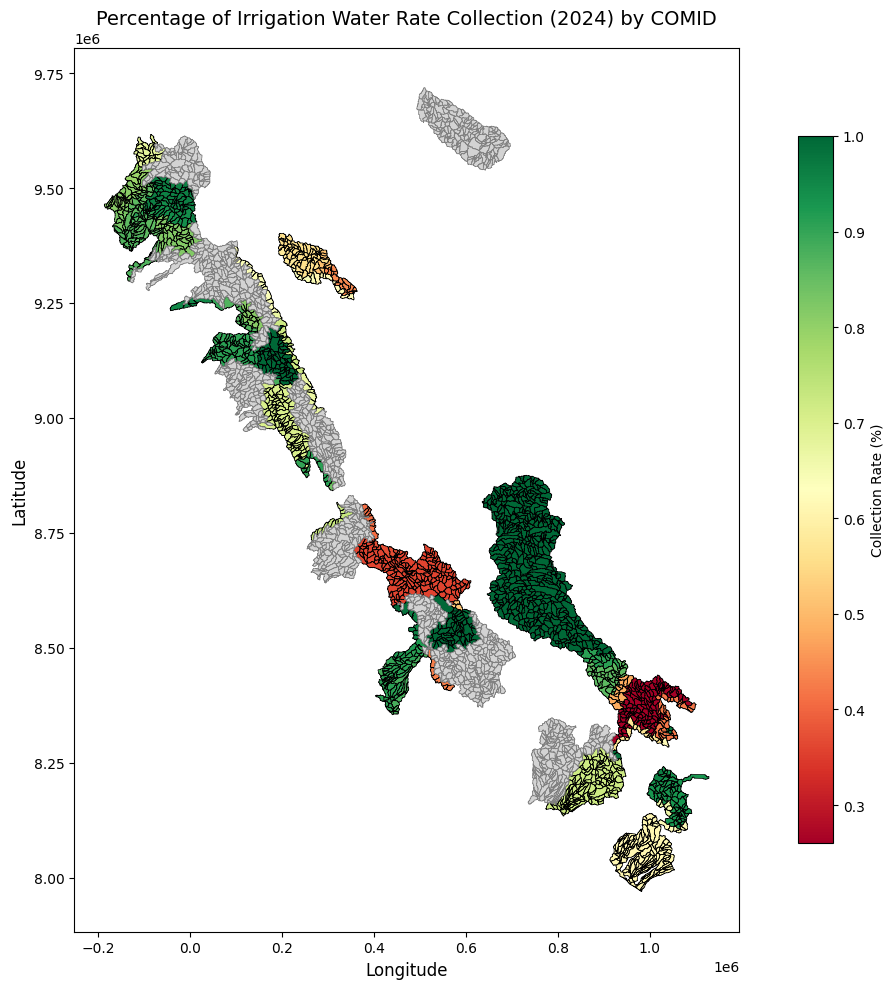

In [6]:
# Plot percentage of irrigation water rate collection
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 10))

subbasins_gdf.plot(column='Pct_Collection', ax=ax, legend=True, 
                   cmap='RdYlGn', edgecolor='black', linewidth=0.5,
                   missing_kwds={'color': 'lightgrey', 'edgecolor': 'grey', 'label': 'No Data'},
                   legend_kwds={'label': 'Collection Rate (%)', 'shrink': 0.8})

ax.set_title('Percentage of Irrigation Water Rate Collection (2024) by COMID', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
plt.tight_layout()
plt.show()

SQLITE INSERT 

In [7]:
#Update relevant dataframe and value column from the calculations above for the specific indicator
insert_data= subbasins_gdf #COMID and IDH
value_column= 'Pct_Collection'

In [8]:
# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Fixed IndID and ScnID (update above)

#For now I am commenting out the looping of scenarios as I imagine we might run just baseline scenarios for now.
# Define the mapping between scenario and DataFrame column
# scenario_columns = {
#     1: 'ACTUAL ANUAL',
#     2: '2030 ANUAL',
#     3: '2050 ANUAL'
# }

# Prepare list of rows to insert
rows_to_insert = []

#for scn_id, column_name in scenario_columns.items():
for _, row in insert_data.iterrows():
    comid = row['COMID']
    value = row[value_column]
    #normalized_value = None  # or compute something like: value / max_value #took out normalized value from the table for now
    rows_to_insert.append((ScnID, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [9]:
rows_to_insert

[(1, 402, 311153600, 0.93),
 (1, 402, 310832400, 0.62),
 (1, 402, 310825700, 0.57),
 (1, 402, 310282400, 0.88),
 (1, 402, 308754600, 0.73),
 (1, 402, 307736500, nan),
 (1, 402, 307078200, 0.91),
 (1, 402, 307183500, 0.91),
 (1, 402, 306538400, 0.95),
 (1, 402, 306599700, 0.95),
 (1, 402, 306319300, nan),
 (1, 402, 306030000, nan),
 (1, 402, 305746400, 0.86),
 (1, 402, 311953100, 0.61),
 (1, 402, 304273900, nan),
 (1, 402, 304281100, nan),
 (1, 402, 304281200, nan),
 (1, 402, 304379300, nan),
 (1, 402, 304274000, nan),
 (1, 402, 304313700, nan),
 (1, 402, 304306400, nan),
 (1, 402, 304327700, nan),
 (1, 402, 304313800, nan),
 (1, 402, 304306300, nan),
 (1, 402, 304321600, nan),
 (1, 402, 304321700, nan),
 (1, 402, 304339400, nan),
 (1, 402, 304335700, nan),
 (1, 402, 304343200, nan),
 (1, 402, 304343100, nan),
 (1, 402, 304335800, nan),
 (1, 402, 304343000, nan),
 (1, 402, 304330900, nan),
 (1, 402, 304352700, nan),
 (1, 402, 304421200, nan),
 (1, 402, 304403000, nan),
 (1, 402, 3043526

In [10]:
# Check for duplicates in the input dataframe before insert
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:", df_check[duplicates])

Duplicates in rows_to_insert: Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [11]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()